# **Gojek Sentiment Analysis**

**Struktur** : 5 Kolom - userName, content (review), score (rating 1-5), at (tanggal), appVersion

**Background** : Gojek sebagai super-app di Indonesia menerima ulasan yang sangat banyak setiap harinya. Perubahan kebijakan, gangguan layanan, maupun pembaruan fitur dapat memicu lonjakan ulasan. Contoh terbaru terjadi pada kebijakan menghapus program GoRide Hemat.

**Goals** : Membangun model LSTM untuk klasifikasi sentiment review jadi positive/negative

---
---

## **Load Data**

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [19]:
df = pd.read_csv('../data/raw/GojekAppReviewV4.0.0-V4.9.3.csv')
df.head()

,userName,content,score,at,appVersion
0,Yuga Edit,akun gopay saya di blok,1,2022-01-21 10:52:12,4.9.3
1,ff burik,Lambat sekali sekarang ini bosssku apk gojek g...,3,2021-11-30 15:40:38,4.9.3
2,Anisa Suci Rahmayuliani,Kenapa sih dari kemarin sy buka aplikasi gojek...,4,2021-11-29 22:58:12,4.9.3
3,naoki yakuza,Baru download gojek dan hape baru trus ditop u...,1,2022-09-03 15:21:17,4.9.3
4,Trio Sugianto,Mantap,5,2022-01-15 10:05:27,4.9.3


In [20]:
print('== Dataset Profile ==')
print(f'Baris: {df.shape[0]}\nKolom: {df.shape[1]} \n')

print('== Missing Values ==')
missing_count = df.isna().sum()
missing_pct = (missing_count / len(df) * 100).round(2)
missing_summary = pd.DataFrame({
    'Total': missing_count,
    'Percentage(%)': missing_pct
})
missing_summary = missing_summary[missing_summary['Total'] > 0].sort_values(by='Total', ascending=False)
print(missing_summary if not missing_summary.empty else 'No missing values found', '\n')

print('== Duplicate Data ==')
print(f'Total Duplicates : {df.duplicated().sum()}\nDuplicate Percentage : {(df.duplicated().sum()/len(df)*100).round(2)}\n')

print('== Column Data Types ==')
print(df.dtypes)

== Dataset Profile ==
Baris: 225002
Kolom: 5 

== Missing Values ==
         Total  Percentage(%)
content      2            0.0 

== Duplicate Data ==
Total Duplicates : 0
Duplicate Percentage : 0.0

== Column Data Types ==
userName        str
content         str
score         int64
at              str
appVersion      str
dtype: object


In [21]:
# Distribusi Rating/Score

print('===== Jumlah =====')
print(df['score'].value_counts().sort_index(), '\n')
print('===== Persen =====')
print((df['score'].value_counts(normalize=True)*100).round(1).sort_index())

===== Jumlah =====
score
1     45229
2      8942
3      9460
4     14316
5    147055
Name: count, dtype: int64 

===== Persen =====
score
1    20.1
2     4.0
3     4.2
4     6.4
5    65.4
Name: proportion, dtype: float64


#### **Distribusi Score Imbalance**

Negatif (1-2) : 24.1% <br>
Netral (3) : 4.2% <br>
Positif (4-5) : 71.8%

---
---

## **Cleaning**

In [22]:
# Drop missing values
df = df.dropna(subset=['content'])

# Drop score netral (3) 4.2%
df = df[df['score'] != 3].reset_index(drop=True)

# Label sentiment, 1=positive 0=negatif
df['sentiment'] = df['score'].apply(lambda x: 1 if x >= 4 else 0)

In [23]:
print('== Dataset Profile ==')
print(f'Baris: {df.shape[0]}\nKolom: {df.shape[1]} \n')
print(df['sentiment'].value_counts(), '\n')
print((df['sentiment'].value_counts(normalize=True)*100).round(1))

== Dataset Profile ==
Baris: 215540
Kolom: 6 

sentiment
1    161369
0     54171
Name: count, dtype: int64 

sentiment
1    74.9
0    25.1
Name: proportion, dtype: float64


In [24]:
# Convert 'at' ke DateTime
df['at'] = pd.to_datetime(df['at'])

In [25]:
print('== Column Data Types ==')
print(df.dtypes)

== Column Data Types ==
userName                 str
content                  str
score                  int64
at            datetime64[us]
appVersion               str
sentiment              int64
dtype: object


---
---

## **Data Manipulation**

In [26]:
# Sample dari total 215k data
n_sample = 50000

df_pos = df[df['sentiment'] == 1].sample(n=n_sample, random_state=42)
df_neg = df[df['sentiment'] == 0].sample(n=n_sample, random_state=42)

df_balanced = pd.concat([df_pos, df_neg]).sample(frac=1, random_state=42).reset_index(drop=True)

print('== Dataset Profile ==')
print(f'Baris: {df_balanced.shape[0]}\nKolom: {df_balanced.shape[1]} \n')
print(df_balanced['sentiment'].value_counts())

== Dataset Profile ==
Baris: 100000
Kolom: 6 

sentiment
0    50000
1    50000
Name: count, dtype: int64


---

#### **Stopword**

In [27]:
# Normalisasi slang

SLANG_DICT = {
    # Negasi
    "gk": "tidak", "ga": "tidak", "gak": "tidak", "g": "tidak",
    "tdk": "tidak", "nggak": "tidak", "ngga": "tidak", "ngg": "tidak",
    "kagak": "tidak", "kaga": "tidak", "engga": "tidak", "enggak": "tidak",
    "gx": "tidak", "kgk": "tidak",

    # Kata ganti
    "gw": "saya", "gue": "saya", "gua": "saya", "sy": "saya", "aku": "saya",
    "ku": "saya", "w": "saya",
    "lu": "kamu", "lo": "kamu", "loe": "kamu", "elu": "kamu",

    # Konjungsi & preposisi
    "yg": "yang", "yng": "yang",
    "dgn": "dengan", "dg": "dengan", "dng": "dengan",
    "tp": "tapi", "tpi": "tapi",
    "krn": "karena", "krna": "karena", "karna": "karena",
    "utk": "untuk", "buat": "untuk", "bt": "untuk",
    "dr": "dari", "dri": "dari",
    "klo": "kalau", "kalo": "kalau", "kl": "kalau",
    "sm": "sama", "sma": "sama",
    "jd": "jadi", "jdi": "jadi",
    "jg": "juga", "jga": "juga",
    "jgn": "jangan", "jng": "jangan",
    "sdh": "sudah", "udh": "sudah", "udah": "sudah", "dah": "sudah",
    "blm": "belum", "blum": "belum", "belom": "belum",

    # Kata sifat / keterangan
    "bgt": "banget", "bngt": "banget", "bngtt": "banget", "bgtt": "banget",
    "bgs": "bagus", "mantap": "bagus", "mantab": "bagus", "mantep": "bagus",
    "mantul": "bagus",
    "jelek": "buruk", "ancur": "hancur", "parah": "buruk",
    "bkn": "bukan",
    "emg": "memang", "emang": "memang", "mmg": "memang",
    "gmn": "bagaimana", "gimana": "bagaimana",
    "gtu": "begitu", "gitu": "begitu", "gt": "begitu",
    "gni": "begini", "gini": "begini",
    "lg": "lagi", "lgi": "lagi",
    "bs": "bisa", "bsa": "bisa",
    "aja": "saja", "aj": "saja", "doang": "saja", "doank": "saja",
    "byk": "banyak", "bnyk": "banyak",
    "skrg": "sekarang", "skrng": "sekarang", "skarang": "sekarang",
    "dl": "dulu", "dlu": "dulu",
    "bnr": "benar", "bner": "benar",
    "sllu": "selalu", "slalu": "selalu",
    "smpe": "sampai", "sampe": "sampai", "smpai": "sampai",
    "pdhl": "padahal",
    "cb": "coba",
    "ngmng": "ngomong", "ngmg": "ngomong",
    "brg": "bareng",
    "trs": "terus", "trus": "terus",
    "mksh": "terima kasih", "makasih": "terima kasih", "makasi": "terima kasih",
    "thx": "terima kasih", "thanks": "terima kasih", "thank": "terima kasih",
    "trims": "terima kasih",
    "tlg": "tolong",
    "pls": "tolong", "please": "tolong",

    # Kata kerja
    "nyoba": "coba", "cobain": "coba",
    "pake": "pakai", "pk": "pakai", "makenya": "pakai",
    "lemot": "lambat",
    "ngebug": "bug",

    # Domain aplikasi
    "apk": "aplikasi", "app": "aplikasi",
    "hp": "handphone", "hape": "handphone",
    "wa": "whatsapp",
    "rek": "rekening",

    # Lain-lain
    "org": "orang", "orng": "orang",
    "knp": "kenapa", "knpa": "kenapa",
    "dmn": "dimana", "dmna": "dimana",
    "kpn": "kapan",
    "smua": "semua", "smw": "semua",
    "hrs": "harus",
    "msh": "masih", "msi": "masih",
    "tgl": "tanggal",
    "nmr": "nomor", "nomer": "nomor",
    "pny": "punya",
    "lbh": "lebih",
    "drpd": "daripada",
    "bgmn": "bagaimana",
    "blg": "bilang",
    "sbnrnya": "sebenarnya", "sbnernya": "sebenarnya",
    "sbg": "sebagai",
}

print(f'Total entri kamus slang: {len(SLANG_DICT)}')

Total entri kamus slang: 156


In [28]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Stopword Sastrawi
stopword_factory = StopWordRemoverFactory()
stopwords = set(stopword_factory.get_stop_words())

NEGATION_WORDS = {"tidak", "bukan", "belum", "tanpa", "jangan", "nggak", "engga", "tak"}
stopwords = stopwords - NEGATION_WORDS

# Custom stopwords
CUSTOM_STOPWORDS = {
    # Brand Gojek
    "gojek", "gopay", "goride", "gocar", "gofood", "gosend",
    "gopaylater", "goplay", "goclub", "gotix",
    
    # Partikel & filler
    "bintang", "dong", "deh", "sih", "nih", "loh", "ya", "yaa",
    "woi", "woy", "halo", "hai", "hi", "nya", "kan", "kok", "lho",
    
    # Kata umum non-sentimen
    "min", "admin", "biar", "banget", "cuma", "terus",
    "pakai", "mau", "makin", "lebih", "sekali", "sangat",
    "jadi", "kasih", "kali", "lama", "baru", "baik",
    "good", "nice", "the", "and",
}

stopwords = stopwords.union(CUSTOM_STOPWORDS)
print(f'Total stopwords: {len(stopwords)} (Sastrawi + custom)\n')

# Verifikasi negasi
print(f'Cek "tidak" di stopwords: {"tidak" in stopwords}')  # Wajib False
print(f'Cek "belum" di stopwords: {"belum" in stopwords}')  # Wajib False
print(f'Cek "jangan" di stopwords: {"jangan" in stopwords}')  # Wajib False

Total stopwords: 167 (Sastrawi + custom)

Cek "tidak" di stopwords: False
Cek "belum" di stopwords: False
Cek "jangan" di stopwords: False


---

#### **Fungsi Preprocessing**

In [29]:
import re
import json
import os
from tqdm import tqdm

# Fungsi Preprocessing

def basic_clean(text):
    """Lowercase, hapus karakter non-alfabet, normalisasi spasi."""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def normalize_repeated_chars(text):
    """'baguuuuus' → 'bagus', 'kereeeen' → 'keren'"""
    return re.sub(r'(.)\1{2,}', r'\1', text)

def normalize_slang(text):
    """Ganti kata slang/gaul ke bentuk formal."""
    words = text.split()
    return " ".join([SLANG_DICT.get(w, w) for w in words])

def apply_word_map(text, word_map):
    """Terapkan mapping stemming + hapus stopwords (kata yg di-map ke '')."""
    words = text.split()
    mapped = [word_map.get(w, w) for w in words]
    return " ".join([w for w in mapped if w])

In [30]:
# Basic Clean
df_balanced['clean_content'] = df_balanced['content'].apply(basic_clean)

# Normalize repeated chars
df_balanced['clean_content'] = df_balanced['clean_content'].apply(normalize_repeated_chars)

# Normalize slang
df_balanced['clean_content'] = df_balanced['clean_content'].apply(normalize_slang)

In [31]:
print('\n=== Sebelum vs Sesudah Normalisasi ===')
print(df_balanced[['content', 'clean_content']].head(10).to_string())


=== Sebelum vs Sesudah Normalisasi ===
                                                                                                                                                                                                                                                                                       content                                                                                                                                                                                                                                                                                  clean_content
0                                                                                                                                                                                                                                                                    Aplikasi  gak bisa login                                                                                                     

---

#### **Stemming**

In [32]:
from multiprocessing import Pool, cpu_count
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

CACHE_PATH = '../data/processed/stem_cache.json'

# Ambil semua kata unik
all_text = " ".join(df_balanced['clean_content'].tolist())
unique_words = set(all_text.split())
print(f'Total kata unik: {len(unique_words)}')

# Cek cache
word_map = {}
if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, 'r', encoding='utf-8') as f:
        word_map = json.load(f)
    print(f'[Cache] {len(word_map)} kata dimuat dari cache.')
    words_to_process = unique_words - set(word_map.keys())
    if not words_to_process:
        print('[Cache] Semua kata sudah ada di cache. Skip stemming!')
    else:
        print(f'[Cache] {len(words_to_process)} kata baru perlu diproses.')
else:
    words_to_process = unique_words
    print('[Cache] Tidak ditemukan. Proses dari awal.')

# Pisahkan: stopword/pendek vs perlu stem
skip_words = {}
stem_candidates = []

for word in words_to_process:
    if word in stopwords or len(word) < 3:
        skip_words[word] = ""
    else:
        stem_candidates.append(word)

word_map.update(skip_words)
print(f'\nDi-skip (stopword/pendek): {len(skip_words)}')
print(f'Perlu di-stem: {len(stem_candidates)}')

Total kata unik: 47990
[Cache] 47990 kata dimuat dari cache.
[Cache] Semua kata sudah ada di cache. Skip stemming!

Di-skip (stopword/pendek): 0
Perlu di-stem: 0


In [33]:
# Stemming dengan Joblib
from joblib import Parallel, delayed

stemmer = StemmerFactory().create_stemmer()

if stem_candidates:
    print(f'Stemming {len(stem_candidates)} kata...\n')

    results = Parallel(n_jobs=-1, backend='loky')(
        delayed(stemmer.stem)(word) for word in tqdm(stem_candidates, desc='Stemming')
    )

    word_map.update(dict(zip(stem_candidates, results)))
    print(f'\n✅ Stemming selesai! Total kata di word_map: {len(word_map)}')
else:
    print('Tidak ada kata baru yang perlu di-stem.')

Tidak ada kata baru yang perlu di-stem.


In [34]:
# Simpan cache
os.makedirs(os.path.dirname(CACHE_PATH), exist_ok=True)
with open(CACHE_PATH, 'w', encoding='utf-8') as f:
    json.dump(word_map, f, ensure_ascii=False)
print(f'[Cache] Disimpan ke {CACHE_PATH} ({len(word_map)} kata)')

[Cache] Disimpan ke ../data/processed/stem_cache.json (47990 kata)


In [35]:
# Terapkan word_map ke teks
print('Applying word map ke seluruh teks...')
df_balanced['clean_content'] = df_balanced['clean_content'].apply(
    lambda x: apply_word_map(x, word_map)
)
print('✅ Selesai!')

Applying word map ke seluruh teks...
✅ Selesai!


---
#### **Perbandingan**

In [36]:
# Bandingkan content asli vs clean
print('=== Hasil Preprocessing ===')
for i in range(5):
    print(f'\n--- Review {i+1} ---')
    print(f'  ASLI  : {df_balanced.loc[i, "content"]}')
    print(f'  BERSIH: {df_balanced.loc[i, "clean_content"]}')

=== Hasil Preprocessing ===

--- Review 1 ---
  ASLI  : Aplikasi  gak bisa login 
  BERSIH: aplikasi tidak login

--- Review 2 ---
  ASLI  : Aplikasi cacat gak bisa transaksi pakai gopay
  BERSIH: aplikasi cacat tidak transaksi

--- Review 3 ---
  ASLI  : sangat membantu
  BERSIH: bantu

--- Review 4 ---
  ASLI  : Apliaksi jan g pernah dapat vocer sering erorlaporam pun percuma g ditanggapinganti aplikasi aja lah
  BERSIH: apliaksi jan tidak pernah vocer sering erorlaporam percuma tidak ditanggapinganti aplikasi lah

--- Review 5 ---
  ASLI  : Tolong kode ot jg adain dong kalo mau log in d hp lain soalnga ini ak pake link g bs masuk2
  BERSIH: kode adain kalau log handphone soalnga link tidak masuk


In [37]:
# Statistik
print('=== Statistik Teks ===')
df_balanced['word_count'] = df_balanced['clean_content'].str.split().str.len()
print(df_balanced['word_count'].describe())
print(f'\nTeks kosong: {(df_balanced["clean_content"].str.strip() == "").sum()}')

=== Statistik Teks ===
count    100000.000000
mean          7.265340
std           8.868848
min           0.000000
25%           1.000000
50%           4.000000
75%          10.000000
max          70.000000
Name: word_count, dtype: float64

Teks kosong: 7235


In [38]:
# Drop teks kosong + re-balance
before = len(df_balanced)
df_balanced = df_balanced[df_balanced['clean_content'].str.strip() != ''].reset_index(drop=True)
print(f'Dropped {before - len(df_balanced)} baris teks kosong')

# Re-balance
min_count = df_balanced['sentiment'].value_counts().min()
df_pos = df_balanced[df_balanced['sentiment'] == 1].sample(n=min_count, random_state=42)
df_neg = df_balanced[df_balanced['sentiment'] == 0].sample(n=min_count, random_state=42)
df_balanced = pd.concat([df_pos, df_neg]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Dataset final: {len(df_balanced)} baris')
print(df_balanced['sentiment'].value_counts())

Dropped 7235 baris teks kosong
Dataset final: 86158 baris
sentiment
1    43079
0    43079
Name: count, dtype: int64


In [39]:
# Simpan clean csv
SAVE_PATH = '../data/processed/gojek_reviews_clean.csv'

cols_to_save = ['content', 'clean_content', 'score', 'sentiment', 'at']
df_balanced[cols_to_save].to_csv(SAVE_PATH, index=False)

print(f'✅ Data tersimpan di {SAVE_PATH}')
print(f'   Shape: {df_balanced[cols_to_save].shape}')

✅ Data tersimpan di ../data/processed/gojek_reviews_clean.csv
   Shape: (86158, 5)


In [40]:
df_balanced.head()

,userName,content,score,at,appVersion,sentiment,clean_content,word_count
0,Saya Saya,Mantap,4,2022-09-22 13:07:39,4.38.2,1,bagus,1
1,sukartinah maria goretti,Oke,5,2023-07-29 21:58:42,4.71.2,1,oke,1
2,Ari Kuswanto,Lag pada aplikasi saat pemesanan dan tidak bis...,1,2023-02-18 13:28:52,4.60.1,0,lag aplikasi mesan tidak mesan padahal masuk p...,13
3,Dhana Cikerls,Dengan Aplikasi Gojek Saya Merasa Istimewa Sem...,5,2022-11-19 15:38:25,4.47.1,1,aplikasi rasa istimewa semangat juang doa baik,7
4,Amri Ajo88,Akhirnya terhapus juga akun saya banyak kebij...,1,2023-11-23 09:10:34,4.78.3,0,akhir hapus akun banyak bijak tidak sesuai,7


---
---

## **EDA: Distribusi & Visualisasi Data**

In [41]:
sns.set_theme(
    style="whitegrid",
    font="sans-serif",
    rc={
        "figure.figsize": (8, 5),
        "axes.edgecolor": "#EAEAEA",
        "grid.color": "#686D76",
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 11
    }
)

---
#### Distribusi Score & Sentiment

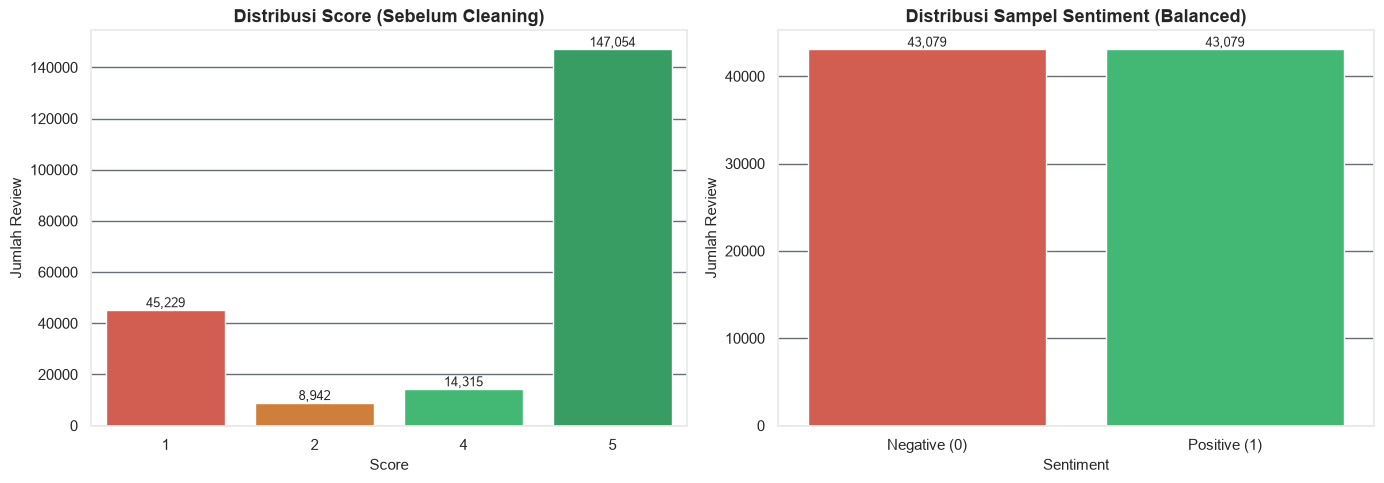

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi Score (sebelum cleaning)
palette_score = {
    1:'#e74c3c', 
    2:'#e67e22', 
    4:'#2ecc71', 
    5:'#27ae60'
    }

sns.countplot(
    data=df, 
    x='score', 
    ax=axes[0], 
    hue='score', 
    palette=palette_score,
    legend=False
)
axes[0].set_title('Distribusi Score (Sebelum Cleaning)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Jumlah Review')

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='{:,.0f}', fontsize=9)

# Distribusi Sentiment (setelah balanced sampling)
palette_sent = {
    0:'#e74c3c', 
    1:'#2ecc71'
    }

sns.countplot(
    data=df_balanced,
    x='sentiment', ax=axes[1],
    hue='sentiment', 
    palette=palette_sent, 
    legend=False
)
axes[1].set_title('Distribusi Sampel Sentiment (Balanced)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Jumlah Review')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Negative (0)', 'Positive (1)'])
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='{:,.0f}', fontsize=9)

plt.tight_layout()
plt.savefig('../assets/01_distribusi_score_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()

---
#### Distribusi Panjang Teks

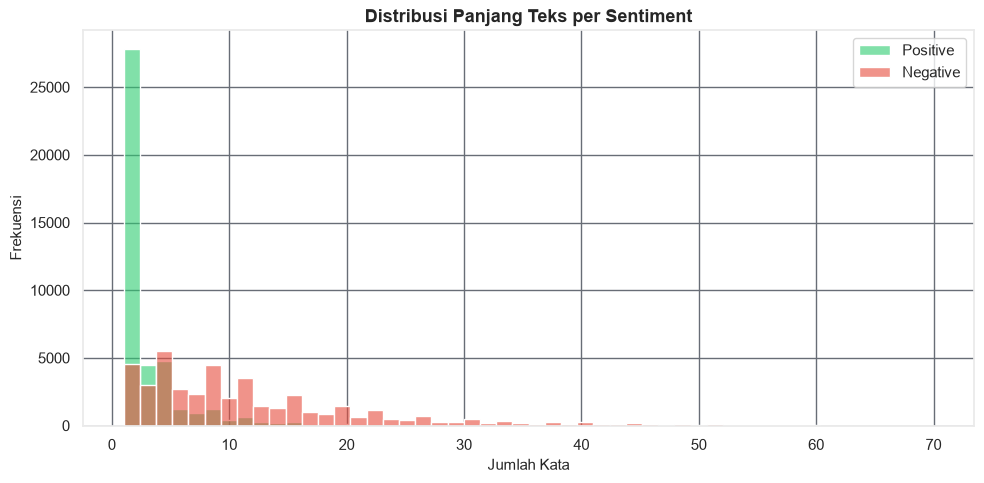

             count       mean       std  min  25%  50%   75%   max
sentiment                                                         
0          43079.0  11.828037  9.943109  1.0  5.0  9.0  16.0  70.0
1          43079.0   3.223102  4.403678  1.0  1.0  2.0   4.0  63.0


In [43]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=df_balanced, 
    x='word_count', 
    hue='sentiment', 
    bins=50, 
    palette={1:'#2ecc71', 0:'#e74c3c'}, 
    alpha=0.6, 
    ax=ax
)
ax.set_title('Distribusi Panjang Teks per Sentiment', fontsize=13, fontweight='bold')
ax.set_xlabel('Jumlah Kata')
ax.set_ylabel('Frekuensi')
ax.legend(labels=['Positive', 'Negative'])

plt.tight_layout()
plt.savefig('../assets/02_distribusi_panjang_teks_per_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()

print(df_balanced.groupby('sentiment')['word_count'].describe())

In [44]:
print(df_balanced['word_count'].describe())

count    86158.000000
mean         7.525569
std          8.811336
min          1.000000
25%          1.000000
50%          4.000000
75%         10.000000
max         70.000000
Name: word_count, dtype: float64


---
#### Top 20 Kata per Sentiment

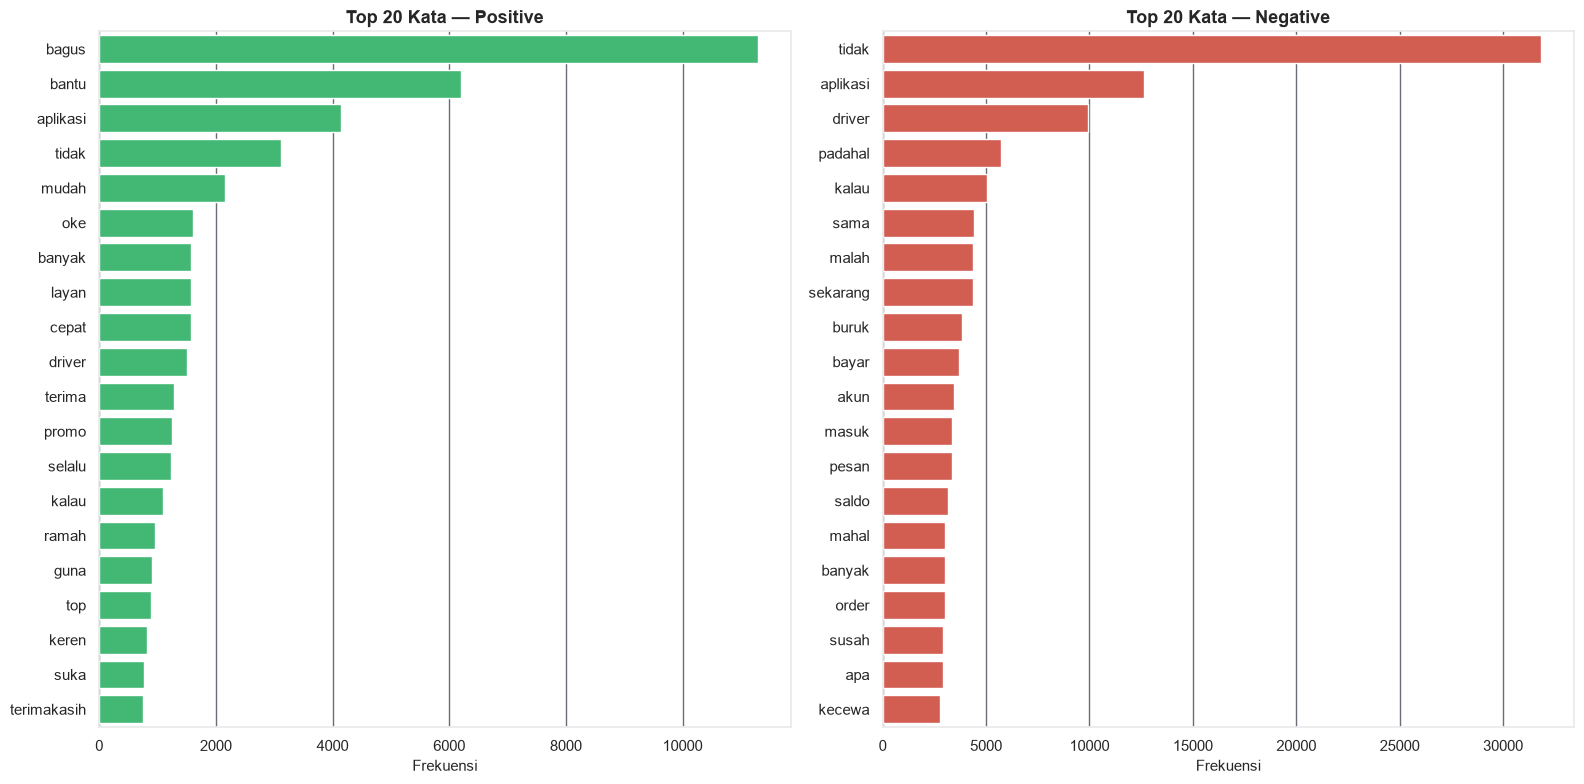

In [45]:
from collections import Counter

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for idx, (label, color, title) in enumerate([
    (1, '#2ecc71', 'Top 20 Kata — Positive'),
    (0, '#e74c3c', 'Top 20 Kata — Negative')
]):
    texts = df_balanced[df_balanced['sentiment'] == label]['clean_content']
    all_words = " ".join(texts).split()
    top_words = Counter(all_words).most_common(20)
    
    words_df = pd.DataFrame(top_words, columns=['kata', 'frekuensi'])
    
    sns.barplot(data=words_df, y='kata', x='frekuensi', color=color, ax=axes[idx])
    axes[idx].set_title(title, fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Frekuensi')
    axes[idx].set_ylabel('')

plt.tight_layout()
plt.savefig('../assets/03_top_20_kata_per_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
from collections import Counter

for label, title in [(1, 'POSITIVE'), (0, 'NEGATIVE')]:
    texts = df_balanced[df_balanced['sentiment'] == label]['clean_content']
    all_words = " ".join(texts).split()
    top_words = Counter(all_words).most_common(20)
    
    print(f'\n=== Top 20 Kata — {title} ===')
    for word, freq in top_words:
        print(f'{word:20s} : {freq:,}')


=== Top 20 Kata — POSITIVE ===
bagus                : 11,286
bantu                : 6,205
aplikasi             : 4,148
tidak                : 3,118
mudah                : 2,150
oke                  : 1,602
banyak               : 1,579
layan                : 1,576
cepat                : 1,571
driver               : 1,499
terima               : 1,286
promo                : 1,243
selalu               : 1,235
kalau                : 1,092
ramah                : 960
guna                 : 911
top                  : 894
keren                : 823
suka                 : 765
terimakasih          : 757

=== Top 20 Kata — NEGATIVE ===
tidak                : 31,838
aplikasi             : 12,653
driver               : 9,905
padahal              : 5,739
kalau                : 5,026
sama                 : 4,434
malah                : 4,385
sekarang             : 4,356
buruk                : 3,831
bayar                : 3,679
akun                 : 3,451
masuk                : 3,373
pesan            

---
#### Word Cloud

Stemming:   1%|          | 576/47383 [00:40<28:41, 27.19it/s]

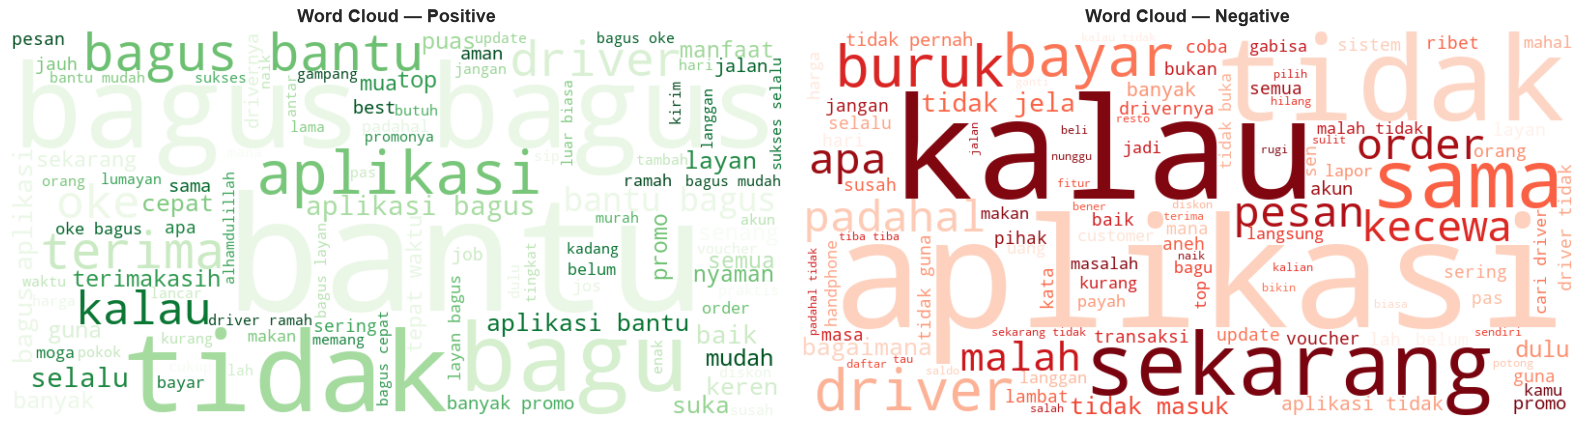

In [47]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (label, cmap, title) in enumerate([
    (1, 'Greens', 'Word Cloud — Positive'),
    (0, 'Reds', 'Word Cloud — Negative')
]):
    text = " ".join(df_balanced[df_balanced['sentiment'] == label]['clean_content'])
    wc = WordCloud(width=800, height=400, background_color='white', 
                   colormap=cmap, max_words=100).generate(text)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(title, fontsize=13, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('../assets/04_word_cloud.png', dpi=150, bbox_inches='tight')
plt.show()

---
## EDA: Insight & Dokumentasi Preprocessing

### 1. Temuan Data Awal
- Dataset berisi **225,002 ulasan**
- Missing value (2 baris di kolom `content`), tidak ada duplikat — data cukup bersih
- Distribusi rating **negative skewed**: score 4-5 mendominasi (71.8%),
  sementara score 1-2 sebesar 24.1%, score 3 hanya 4.2%

### 2. Keputusan Labeling & Sampling
- Dipilih pendekatan **binary sentiment** (positive vs negative) dengan menghapus score 3 (netral),
  karena kelas netral hanya 4.2% dan berpotensi menyulitkan model
- Label: score 4–5 → **Positive (1)**, score 1–2 → **Negative (0)**
- Dilakukan balanced sampling **50,000 per kelas** (100,000 total) untuk menghindari bias model
  terhadap kelas mayoritas

### 3. Dokumentasi Preprocessing Pipeline
Tahapan preprocessing yang diterapkan secara berurutan:

| Tahap | Fungsi | Contoh |
|-------|--------|--------|
| Lowercase | Normalisasi huruf | `"BAGUS"` → `"bagus"` |
| Hapus karakter non-alfabet | Hilangkan angka, simbol, emoji | `"bagus!!!"` → `"bagus"` |
| Normalize repeated chars | Reduksi huruf berulang | `"baguuuus"` → `"bagus"` |
| Slang normalization | Ganti kata gaul ke formal | `"gak"` → `"tidak"`, `"hp"` → `"handphone"` |
| Stopword removal | Hapus kata tidak bermakna | `"yang"`, `"dan"`, `"di"` → dihapus |
| Stemming (Sastrawi) | Kembalikan ke kata dasar | `"membantu"` → `"bantu"` |

**Catatan penting**: Kata negasi (`tidak`, `belum`, `jangan`, `nggak`, dll) 
**sengaja dipertahankan** dari stopword removal — karena kata ini krusial untuk 
membedakan sentiment (contoh: *"tidak bagus"* vs *"bagus"* punya makna berbeda)

### 4. Hasil Setelah Preprocessing
- 7,235 teks menjadi kosong setelah preprocessing (review sangat pendek, 
  misal hanya berisi emoji atau angka) → di-drop
- Dataset final: **86,158 baris** (43,079 positive, 43,079 negative) — perfectly balanced
- Rata-rata panjang teks setelah cleaning: **~7 kata** per review (teks pendek mendominasi)
- Panjang maksimal: 70 kata

### 5. Insight dari Visualisasi
- **Word Cloud & Top 20 Kata Positive**: didominasi kata seperti `bagus`, `bantu`, `murah` `mudah`, `cepat`
- **Word Cloud & Top 20 Kata Negative**: didominasi kata seperti `tidak`, `kecewa`, `buruk`, `lama`, `gagal`


Data hasil preprocessing disimpan di `data/processed/gojek_reviews_clean.csv` dan stem cache di `data/processed/stem_cache.json`.